#Basic codes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')
import json
import glob
import cv2

Mounted at /content/drive


#New codes

In [3]:
sub_path = '/content/drive/MyDrive/sub'

all_bhmdot = []
all_sfr = []

for folder_num in range(100):
    save_file_path = os.path.join(sub_path, f'sb{folder_num}.npz')

    if os.path.exists(save_file_path):
        loaded_data = np.load(save_file_path)
        all_bhmdot.append(loaded_data['bhmdot'])
        all_sfr.append(loaded_data['sfr'])
    else:
        print(f"File not found {folder_num}: {save_file_path}")

if all_bhmdot and all_sfr:
    final_bhmdot = np.concatenate(all_bhmdot)
    final_sfr = np.concatenate(all_sfr)

    print(f"Loaded the data from {len(all_bhmdot)} files.")

    print(f"First 10 elements of final_bhmdot: {final_bhmdot[:10]}")

    print(f"First 10 elements of final_sfr: {final_sfr[:10]}")
else:
    print("No data files were found or loaded.")

Loaded the data from 100 files.
First 10 elements of final_bhmdot: [0.00351652 0.0166792  0.00102882 0.00874955 0.00163583 0.00256499
 0.00037256 0.00249654 0.00077815 0.00277787]
First 10 elements of final_sfr: [410.991     61.4731    19.4075    18.2909     6.63607    7.76953
   0.433356   4.90325    4.00612    1.93112 ]


In [5]:
bhl = 1e4*final_bhmdot[(final_bhmdot != -1) & (final_bhmdot != 0)]
sfrl = final_sfr[(final_sfr != -1) & (final_sfr != 0)].tolist()

bins = np.logspace(-7, 3, 100)

counts1, bin_edges = np.histogram(bhl, bins=bins)
counts2, bin_edges = np.histogram(sfrl, bins=bins)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])


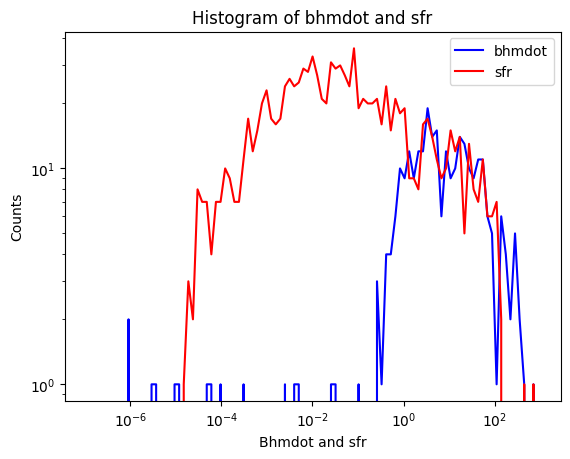

In [6]:
plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Counts')
plt.xlabel('Bhmdot and sfr')
plt.legend()
plt.show()

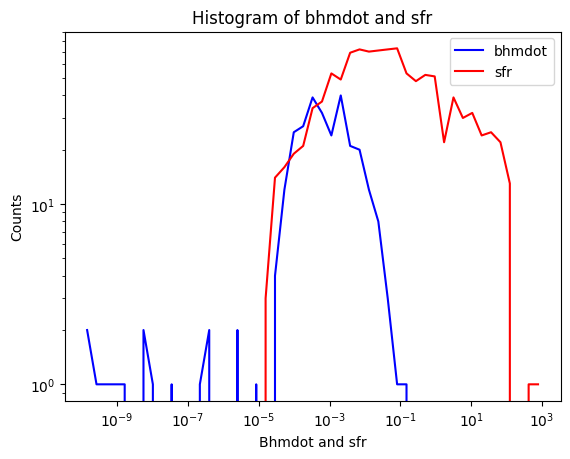

In [7]:
bhl = final_bhmdot[(final_bhmdot != -1) & (final_bhmdot != 0)].tolist()
sfrl = final_sfr[(final_sfr != -1) & (final_sfr != 0)].tolist()

bins = np.logspace(-10, 3, 50)

counts1, bin_edges = np.histogram(bhl, bins=bins)
counts2, bin_edges = np.histogram(sfrl, bins=bins)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Counts')
plt.xlabel('Bhmdot and sfr')
plt.legend()
plt.show()